# handling DEM as input to WWFS #

In [1]:
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio.transform import from_origin, Affine
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.features import shapes
from rasterio.warp import aligned_target
from shapely.geometry import shape
import geopandas as gpd
from scipy.interpolate import griddata
from osgeo import gdal, gdalconst
import xdem
import matplotlib.pyplot as plt
from xdem.coreg.workflows import dem_coregistration
import os
from shapely.geometry import box
import rioxarray
import rasterio.plot





In [2]:
datadir_in = "/scratch-3/cogier/data/DEM_input"
datadir_out = "/scratch-3/cogier/data/DEM_output"

### import bedrock in Swiss coordinates ###

/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/geoutils/raster/raster.py:1739: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


CRS.from_epsg(2056)

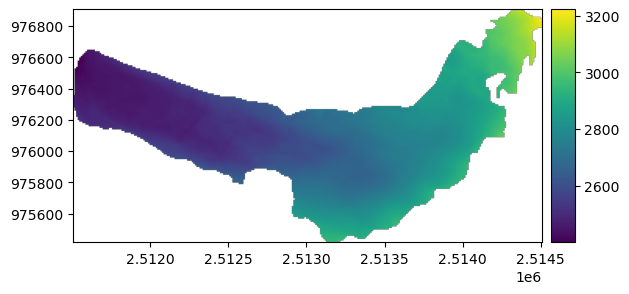

In [21]:
bed_lv95 = xdem.DEM(os.path.join(datadir_in, "grid_bedrock_10m.tif"))
bed_ige = xdem.DEM(os.path.join(datadir_in, "Bedrock.tif"))
bed_lv95.plot()
bed_lv95.res
bed_lv95.crs


### Reprojection Swiss to Lambert 93 ###

(9.989329565440551, 9.989329565440551)

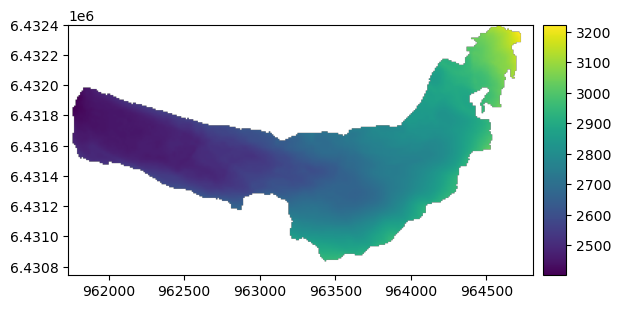

In [22]:
bed_lambert = bed_lv95.reproject(crs='EPSG:2154')
bed_lambert.save(os.path.join(datadir_out, "Bedrock_reproj.tif"))
bed_lambert.plot() #--> no stripes (= good) but shifted to the north --> needs co registration
bed_lambert.res


(10.683080483055157, 10.68308048305372)

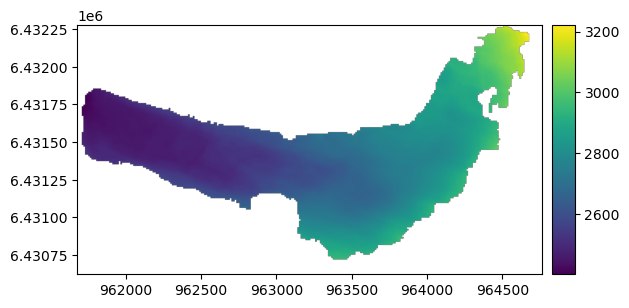

In [11]:
bed_ige_corr = bed_ige.reproject(resampling=Resampling.bilinear)
bed_ige_corr.plot()
bed_lambert.save(os.path.join(datadir_out, "Bedrock_resample_bilinear.tif"))

bed_ige.res

In [50]:
bed_ige.res[0]

10.683080483055157

### Resample using Gdal ###

In [45]:
from osgeo import gdal

# Open the input DEM explicitly with gdal.OpenEx
src_ds = gdal.OpenEx(os.path.join(datadir_in, "Bedrock.tif"), gdal.OF_RASTER)

# Define output file name
output_file = os.path.join(datadir_out, "Bedrock_resample_cubic.tif")

# Perform resampling (bilinear method)
gdal.Warp(output_file, src_ds, xRes=10, yRes=10, resampleAlg=gdal.GRA_Cubic)

# Close dataset
src_ds = None


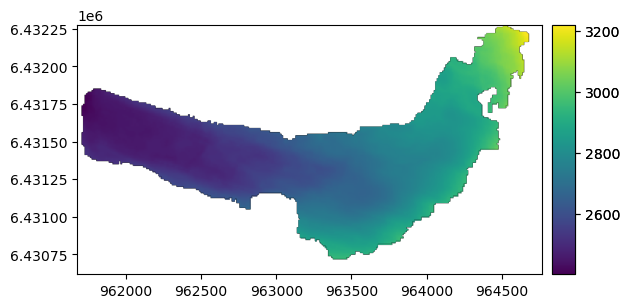

In [46]:
bed_ige_corr = xdem.DEM(os.path.join(datadir_out, "Bedrock_resample_cubic.tif"))
bed_ige.plot()
bed_ige_corr.plot()

In [ ]:
! gdalwarp -r cubic -tr 10.683080483055157 10.68308048305372 -of GTiff /scratch-3/cogier/data/DEM_input/Bedrock.tif /scratch-3/cogier/data/DEM_output/Bedrock_resampled_gdal.tif

ERROR 1: Output dataset /scratch-3/cogier/data/DEM_output/Bedrock_resampled_gdal.tif exists,
but some command line options were provided indicating a new dataset
should be created.  Please delete existing dataset and run again.



In [53]:
! gdalsrsinfo -o epsg /scratch-3/cogier/data/DEM_input/Bedrock.tif



EPSG:2154



In [56]:
! rm /scratch-3/cogier/data/DEM_output/Bedrock_resampled_gdalbis.tif 
! gdalwarp -t_srs $(gdalsrsinfo -o epsg /scratch-3/cogier/data/DEM_input/Bedrock.tif) -r cubic -of GTiff /scratch-3/cogier/data/DEM_input/grid_bedrock_10m.tif /scratch-3/cogier/data/DEM_output/Bedrock_resampled_gdalbis.tif


Creating output file that is 308P x 166L.
Processing /scratch-3/cogier/data/DEM_input/grid_bedrock_10m.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


### Enlarge dem_ige so it's not cut off after co-registration ###

In [36]:
bed_ige_corr.bounds


BoundingBox(left=961677.8660997689, bottom=6430622.411740035, right=964765.2763593718, top=6432278.289214908)

In [37]:
bed_ige.bounds


BoundingBox(left=961677.8660997689, bottom=6430622.411740035, right=964765.2763593718, top=6432278.289214908)

In [10]:
assert bed_lambert.crs == bed_ige.crs, "CRS mismatch! Reprojection required."

In [34]:
# Compute new bounds (union of both DEMs)
xmin = min(bed_ige.bounds.left, bed_lambert.bounds.left)
ymin = min(bed_ige.bounds.bottom, bed_lambert.bounds.bottom)
xmax = max(bed_ige.bounds.right, bed_lambert.bounds.right)
ymax = max(bed_ige.bounds.top, bed_lambert.bounds.top)

In [41]:
# Compute new transform & dimensions to fit the new bounds
dst_transform, dst_width, dst_height = aligned_target(
    transform=bed_ige.transform,
    width=int((xmax - xmin) / bed_ige.res[0]),  # Compute new width
    height=int((ymax - ymin) / bed_ige.res[1]),  # Compute new height
    resolution=bed_ige.res  # Keep original resolution
)

In [ ]:
# Create new padded array filled with NoData values
padded_data = np.full((dst_height, dst_width), bed_ige.nodata, dtype=bed_ige.data.dtype)

-9999.0

In [50]:
# Copy original data into the correct position within the new array
row_off = int((bed_ige.bounds.top - ymax) / bed_ige.res[1])  # Row offset
col_off = int((xmin - bed_ige.bounds.left) / bed_ige.res[0])  # Column offset
row_off


-11

/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/geoutils/raster/raster.py:1777: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical operation, use astype() prior to the operation to convert to a data type that won't derive the nodata values (e.g., a float type).
  warnings.warn(
/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/geoutils/raster/raster.py:1777: UserWarning: Unmasked values equal to the nodata value found in data array. They are now masked.
 If this happened when creating or updating the array, to silence this warning, convert nodata values in the array to np.nan or mask them with np.ma.masked prior to creating or updating the raster.
If this happened during a numerical 

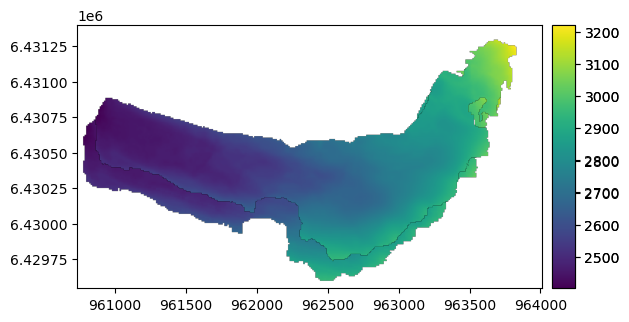

In [12]:

def pad_dem(dem, pad_meters=100):
    """Pads a DEM by a given distance (meters) with NoData values."""
    
    # Convert padding distance into pixels
    extra_pixels = int(pad_meters / dem.res[0])  # Assuming square pixels
    
    # Compute new dimensions
    new_height = dem.shape[0] + 2 * extra_pixels
    new_width = dem.shape[1] + 2 * extra_pixels
    
    # Create a larger array filled with NoData value
    padded_data = np.full((new_height, new_width), dem.nodata, dtype=dem.data.dtype)
    
    # Insert original data into the center of the new array
    padded_data[extra_pixels:-extra_pixels, extra_pixels:-extra_pixels] = dem.data
    
    # Adjust the affine transform: shift upper-left corner
    new_transform = dem.transform * Affine.translation(-extra_pixels * dem.res[0], 
                                                       extra_pixels * dem.res[1])  # Y shift is positive
    
    # Create a new padded DEM
    return xdem.DEM.from_array(padded_data, new_transform, dem.crs, nodata=dem.nodata)

# Apply padding to both DEMs
bed_ige_padded = pad_dem(bed_ige, pad_meters=100)
bed_lambert_padded = pad_dem(bed_lambert, pad_meters=100)
bed_ige_padded.plot()
bed_lambert_padded.plot()

In [76]:
bed_ige_padded.info()

Driver:               None 
Opened from file:     None 
Filename:             None 
Loaded?               True 
Modified since load?  True 
Grid size:            489, 355
Number of bands:      1
Data types:           float32
Coordinate system:    ['EPSG:2154']
Nodata value:         -9999.0
Pixel interpretation: None
Pixel size:           10.683080483055157, 10.68308048305372
Upper left corner:    950265.0452390255, 6417072.974782683
Lower right corner:   955489.0715952395, 6420865.468354167



### coregistration to fit Lambert outline (a.k.a ige dem) ###

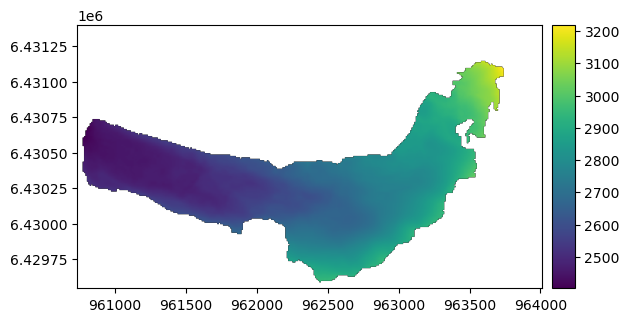

<Axes: >

In [47]:
coreg_method = xdem.coreg.NuthKaab()
coreg_method.fit(reference_elev=bed_ige_padded, to_be_aligned_elev=bed_lambert_padded)
bed_aligned = coreg_method.apply(bed_lambert_padded)
bed_aligned.plot()
bed_aligned.save(os.path.join(datadir_out, "Bedrock_reproj_aligned.tif"))

# XDEM to RASTERIO object
bed_aligned = bed_aligned.to_rio_dataset()
rasterio.plot.show(bed_aligned)  # Plot raster

In [82]:
type(bed_aligned)

rasterio.io.DatasetReader

## Mask and glacier outline (LV95) ##

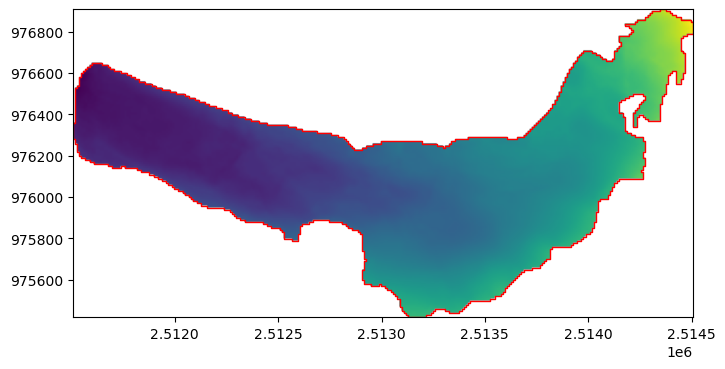

In [74]:

# Read the first band of the raster (assuming it's a single-band raster)
bed_lv95_rio = bed_lv95.to_rio_dataset()
bed_mask_data = bed_lv95_rio.read(1)  # Extracts the raster as a NumPy array

# Convert to a binary mask (if needed)
bed_mask_data = (bed_mask_data > 0).astype(np.uint8)

# Extract shapes directly using the transform from bed_mask
shapes_gen = shapes(bed_mask_data, transform=bed_lv95_rio.transform)

# Convert shapes to geometries
geometries = [shape(geom) for geom, value in shapes_gen if value == 1]

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=geometries, crs=bed_lv95_rio.crs.to_wkt())

# Save to a shapefile
gdf.to_file(os.path.join(datadir_out,"bed_outline_lv95.shp"))

# Open the raster from bed_mask directly
fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(bed_lv95_rio, ax=ax)  # Plot raster
gdf.plot(ax=ax, edgecolor='red', facecolor="none")  # Overlay shapefile
plt.show()


In [69]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

## Import surface DEMs (and crop) ##

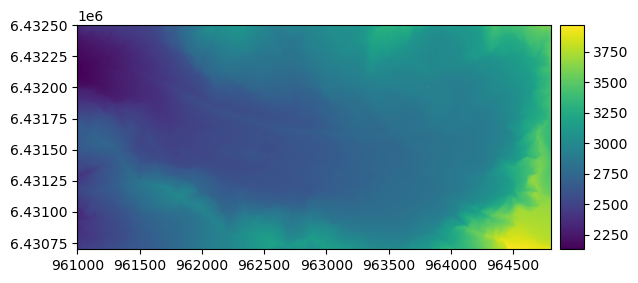

In [ ]:
surf_21 = rioxarray.open_rasterio(os.path.join(datadir_in, "Berarde_Res1.0_CompElevmean_merged.tif"),chunks="auto")
#list(bed_aligned.bounds)
surf_21_cropp = surf_21.rio.clip_box(961000, 6430700, 964800, 6432500)
#ds.rio.clip(gdf["geometry"]) #for clipping form outline?
surf_21_cropp.rio.to_raster(os.path.join(datadir_out, "Berarde_Res1.0_crop.tif"))
surf_21_crop = xdem.DEM(os.path.join(datadir_out, "Berarde_Res1.0_crop.tif"))
#surf_21_crop.plot()


# Plot DEM using xdem's plot function
surf_21_crop.plot()  # Plot DEM object from xdem




In [133]:
# mosaic

# try different sampling
# execute WWFS in a loop
# check sink bounds and stuff
# plot histogram of sublake

In [84]:
surf_21_crop_lv95 = surf_21_crop.reproject(crs='EPSG:2056',resampling=Resampling.bilinear)
surf_21_crop_lv95.res
surf_21_crop_lv95.save(os.path.join(datadir_out, "Berarde_Res1.0_crop_lv95.tif"))



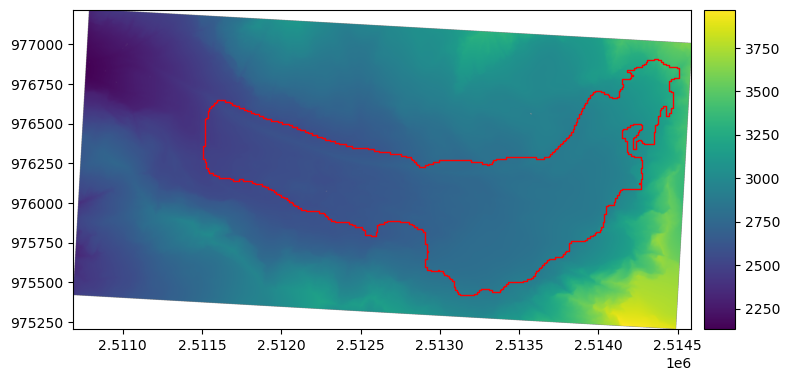

In [85]:


fig, ax = plt.subplots(figsize=(8, 8))

# Plot DEM using xdem's plot function
surf_21_crop_lv95.plot(ax=ax)  # Plot DEM on the same axes

# Overlay shapefile
gdf.plot(ax=ax, edgecolor='red', facecolor="none")  # Overlay shapefile on the same axes

plt.show()